<a href="https://colab.research.google.com/github/rickiepark/deep-learning-with-python-3rd/blob/main/chapter13_timeseries-forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

이 노트북은 <[케라스 창시자에게 배우는 딥러닝 (개정 3판)](https://tensorflow.blog/kerasdl3/)>(길벗, 2026)의 예제 코드를 담고 있습니다.

In [1]:
!pip install keras keras-hub --upgrade -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 38.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 43.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 230.0/230.0 kB 16.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 23.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
keras-nlp 0.26.0 requires keras-hub==0.26.0, but you have keras-hub 0.31.0 which is incompatible.


In [2]:
import os
os.environ["KERAS_BACKEND"] = "jax"

In [3]:
# @title
import os
from IPython.core.magic import register_cell_magic

@register_cell_magic
def backend(line, cell):
    current, required = os.environ.get("KERAS_BACKEND", ""), line.split()[-1]
    if current == required:
        get_ipython().run_cell(cell)
    else:
        print(
            f"이 셀은 {required} 백엔드가 필요합니다. 실행을 위해 노트북 서두에서 KERAS_BACKEND를 "
            f"\"{required}\"로 바꾸고 런타임을 재식한 다음 노트북을 다시 실행하세요."
        )

In [4]:
import keras, keras_hub

print(keras.__version__)
print(keras_hub.__version__)

3.15.1
0.31.0


## 시계열 예측

### 다양한 종류의 시계열 작업

### 온도 예측 문제

In [5]:
!wget https://s3.amazonaws.com/keras-datasets/jena_climate_2009_2016.csv.zip
!unzip jena_climate_2009_2016.csv.zip

--2026-08-14 13:53:45--  https://s3.amazonaws.com/keras-datasets/jena_climate_2009_2016.csv.zip
Resolving s3.amazonaws.com (s3.amazonaws.com)... 54.231.135.72, 16.182.104.88, 16.182.105.216, ...
Connecting to s3.amazonaws.com (s3.amazonaws.com)|54.231.135.72|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 13565642 (13M) [application/zip]
Saving to: ‘jena_climate_2009_2016.csv.zip’

jena_climate_2009_2 100%[===================>]  12.94M  21.8MB/s    in 0.6s    

2026-08-14 13:53:46 (21.8 MB/s) - ‘jena_climate_2009_2016.csv.zip’ saved [13565642/13565642]

Archive:  jena_climate_2009_2016.csv.zip
  inflating: jena_climate_2009_2016.csv  
  inflating: __MACOSX/._jena_climate_2009_2016.csv  


In [6]:
import os

fname = os.path.join("jena_climate_2009_2016.csv")

with open(fname) as f:
    data = f.read()

lines = data.split("\n")
header = lines[0].split(",")
lines = lines[1:]
print(header)
print(len(lines))

['"Date Time"', '"p (mbar)"', '"T (degC)"', '"Tpot (K)"', '"Tdew (degC)"', '"rh (%)"', '"VPmax (mbar)"', '"VPact (mbar)"', '"VPdef (mbar)"', '"sh (g/kg)"', '"H2OC (mmol/mol)"', '"rho (g/m**3)"', '"wv (m/s)"', '"max. wv (m/s)"', '"wd (deg)"']
420451


In [7]:
import numpy as np

temperature = np.zeros((len(lines),))
raw_data = np.zeros((len(lines), len(header) - 1))

for i, line in enumerate(lines):
    values = [float(x) for x in line.split(",")[1:]]
    temperature[i] = values[1]
    raw_data[i, :] = values[:]

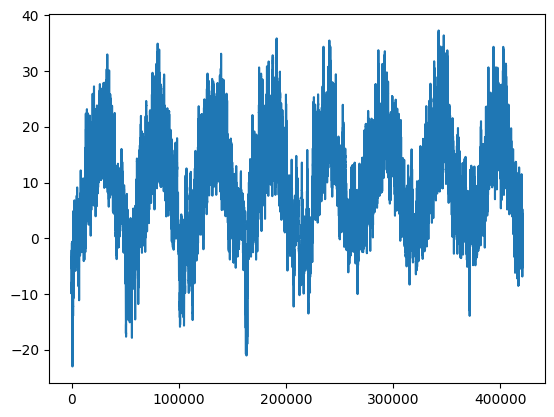

In [8]:
from matplotlib import pyplot as plt

plt.plot(range(len(temperature)), temperature)

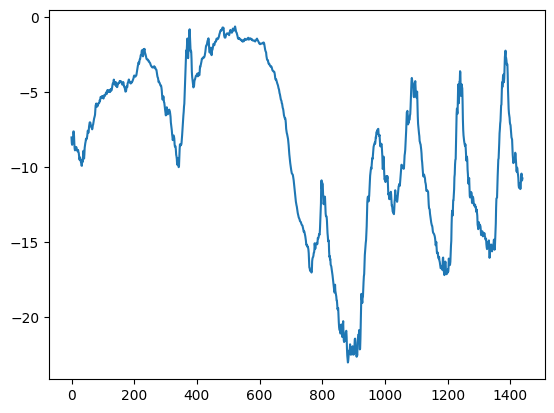

In [9]:
plt.plot(range(1440), temperature[:1440])

In [10]:
num_train_samples = int(0.5 * len(raw_data))
num_val_samples = int(0.25 * len(raw_data))
num_test_samples = len(raw_data) - num_train_samples - num_val_samples
print("num_train_samples:", num_train_samples)
print("num_val_samples:", num_val_samples)
print("num_test_samples:", num_test_samples)

num_train_samples: 210225
num_val_samples: 105112
num_test_samples: 105114


#### 데이터 준비

In [11]:
mean = raw_data[:num_train_samples].mean(axis=0)
raw_data -= mean
std = raw_data[:num_train_samples].std(axis=0)
raw_data /= std

In [12]:
import numpy as np
import keras

int_sequence = np.arange(10)
dummy_dataset = keras.utils.timeseries_dataset_from_array(
    data=int_sequence[:-3],
    targets=int_sequence[3:],
    sequence_length=3,
    batch_size=2,
)

for inputs, targets in dummy_dataset:
    for i in range(inputs.shape[0]):
        print([int(x) for x in inputs[i]], int(targets[i]))

[0, 1, 2] 3
[1, 2, 3] 4
[2, 3, 4] 5
[3, 4, 5] 6
[4, 5, 6] 7


In [13]:
sampling_rate = 6
sequence_length = 120
delay = sampling_rate * (sequence_length + 24 - 1)
batch_size = 256

train_dataset = keras.utils.timeseries_dataset_from_array(
    raw_data[:-delay],
    targets=temperature[delay:],
    sampling_rate=sampling_rate,
    sequence_length=sequence_length,
    shuffle=True,
    batch_size=batch_size,
    start_index=0,
    end_index=num_train_samples,
)

val_dataset = keras.utils.timeseries_dataset_from_array(
    raw_data[:-delay],
    targets=temperature[delay:],
    sampling_rate=sampling_rate,
    sequence_length=sequence_length,
    shuffle=True,
    batch_size=batch_size,
    start_index=num_train_samples,
    end_index=num_train_samples + num_val_samples,
)

test_dataset = keras.utils.timeseries_dataset_from_array(
    raw_data[:-delay],
    targets=temperature[delay:],
    sampling_rate=sampling_rate,
    sequence_length=sequence_length,
    shuffle=True,
    batch_size=batch_size,
    start_index=num_train_samples + num_val_samples,
)

In [14]:
for samples, targets in train_dataset:
    print("샘플 크기:", samples.shape)
    print("타깃 크기:", targets.shape)
    break

샘플 크기: (256, 120, 14)
타깃 크기: (256,)


#### 상식 수준의 기준점

In [15]:
def evaluate_naive_method(dataset):
    total_abs_err = 0.0
    samples_seen = 0
    for samples, targets in dataset:
        preds = samples[:, -1, 1] * std[1] + mean[1]
        total_abs_err += np.sum(np.abs(preds - targets))
        samples_seen += samples.shape[0]
    return total_abs_err / samples_seen

print(f"검증 MAE: {evaluate_naive_method(val_dataset):.2f}")
print(f"테스트 MAE: {evaluate_naive_method(test_dataset):.2f}")

검증 MAE: 2.44
테스트 MAE: 2.62


#### 기본적인 머신 러닝 모델 시도해 보기

In [16]:
import keras
from keras import layers

inputs = keras.Input(shape=(sequence_length, raw_data.shape[-1]))
x = layers.Flatten()(inputs)
x = layers.Dense(16, activation="relu")(x)
outputs = layers.Dense(1)(x)
model = keras.Model(inputs, outputs)

callbacks = [
    keras.callbacks.ModelCheckpoint("jena_dense.keras", save_best_only=True)
]
model.compile(optimizer="adam", loss="mse", metrics=["mae"])
history = model.fit(
    train_dataset,
    epochs=10,
    validation_data=val_dataset,
    callbacks=callbacks,
)

model = keras.models.load_model("jena_dense.keras")
print(f"테스트 MAE: {model.evaluate(test_dataset)[1]:.2f}")

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


Epoch 1/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 44s 52ms/step - loss: 13.6707 - mae: 2.8255 - val_loss: 10.5021 - val_mae: 2.5529
Epoch 2/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 39s 47ms/step - loss: 8.6137 - mae: 2.2998 - val_loss: 10.4933 - val_mae: 2.5577
Epoch 3/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 39s 47ms/step - loss: 7.7179 - mae: 2.1808 - val_loss: 10.5105 - val_mae: 2.5653
Epoch 4/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 38s 46ms/step - loss: 7.1985 - mae: 2.1086 - val_loss: 10.7963 - val_mae: 2.6058
Epoch 5/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 42s 51ms/step - loss: 6.9018 - mae: 2.0651 - val_loss: 10.8482 - val_mae: 2.6123
Epoch 6/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 40s 49ms/step - loss: 6.6721 - mae: 2.0311 - val_loss: 11.2171 - val_mae: 2.6541
Epoch 7/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 39s 47ms/step - loss: 6.4768 - mae: 2.0009 - val_loss: 11.5892 - val_mae: 2.7046
Epoch 8/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 41s 50ms/step - loss: 6.3194 - mae: 1.9753 - val_loss: 11.1553 - val_mae: 2.6473
Epoch 9/10
819/819 ━━━━━━━━━━━━

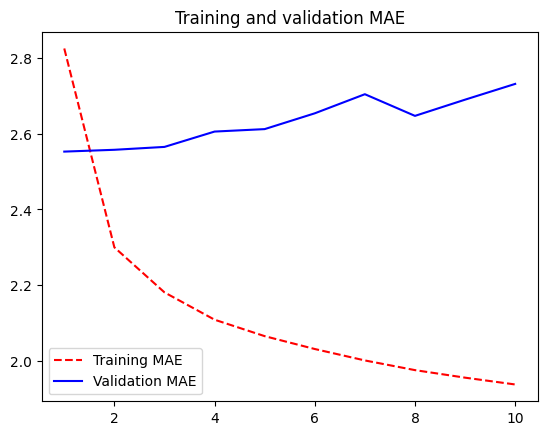

In [17]:
import matplotlib.pyplot as plt

loss = history.history["mae"]
val_loss = history.history["val_mae"]
epochs = range(1, len(loss) + 1)
plt.figure()
plt.plot(epochs, loss, "r--", label="Training MAE")
plt.plot(epochs, val_loss, "b", label="Validation MAE")
plt.title("Training and validation MAE")
plt.legend()
plt.show()

#### 1D 합성곱 모델 시도해 보기

In [18]:
inputs = keras.Input(shape=(sequence_length, raw_data.shape[-1]))
x = layers.Conv1D(8, 24, activation="relu")(inputs)
x = layers.MaxPooling1D(2)(x)
x = layers.Conv1D(8, 12, activation="relu")(x)
x = layers.MaxPooling1D(2)(x)
x = layers.Conv1D(8, 6, activation="relu")(x)
x = layers.GlobalAveragePooling1D()(x)
outputs = layers.Dense(1)(x)
model = keras.Model(inputs, outputs)

callbacks = [
    keras.callbacks.ModelCheckpoint("jena_conv.keras", save_best_only=True)
]
model.compile(optimizer="adam", loss="mse", metrics=["mae"])
history = model.fit(
    train_dataset,
    epochs=10,
    validation_data=val_dataset,
    callbacks=callbacks,
)

model = keras.models.load_model("jena_conv.keras")
print(f"테스트 MAE: {model.evaluate(test_dataset)[1]:.2f}")

Epoch 1/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 45s 52ms/step - loss: 21.8657 - mae: 3.6166 - val_loss: 14.4128 - val_mae: 3.0108
Epoch 2/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 39s 47ms/step - loss: 13.8710 - mae: 2.9589 - val_loss: 13.7265 - val_mae: 2.9444
Epoch 3/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 39s 47ms/step - loss: 12.6282 - mae: 2.8221 - val_loss: 13.9328 - val_mae: 2.9497
Epoch 4/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 42s 51ms/step - loss: 11.7655 - mae: 2.7211 - val_loss: 13.9846 - val_mae: 2.9624
Epoch 5/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 41s 50ms/step - loss: 11.2244 - mae: 2.6547 - val_loss: 14.0144 - val_mae: 2.9608
Epoch 6/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 41s 50ms/step - loss: 10.6234 - mae: 2.5815 - val_loss: 14.5344 - val_mae: 3.0153
Epoch 7/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 40s 48ms/step - loss: 10.2537 - mae: 2.5385 - val_loss: 14.8479 - val_mae: 3.0561
Epoch 8/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 40s 49ms/step - loss: 9.8116 - mae: 2.4843 - val_loss: 14.9066 - val_mae: 3.0567
Epoch 9/10
819/819 ━━━━━━

### 순환 신경망

In [26]:
inputs = keras.Input(shape=(sequence_length, raw_data.shape[-1]))
x = layers.LSTM(16)(inputs)
outputs = layers.Dense(1)(x)
model = keras.Model(inputs, outputs)

callbacks = [
    keras.callbacks.ModelCheckpoint("jena_lstm.keras", save_best_only=True)
]
model.compile(optimizer="adam", loss="mse", metrics=["mae"])
history = model.fit(
    train_dataset,
    epochs=10,
    validation_data=val_dataset,
    callbacks=callbacks,
)

model = keras.models.load_model("jena_lstm.keras")
print(f"테스트 MAE: {model.evaluate(test_dataset)[1]:.2f}")

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


Epoch 1/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 50s 60ms/step - loss: 84.7842 - mae: 7.4421 - val_loss: 62.5682 - val_mae: 6.4976
Epoch 2/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 45s 54ms/step - loss: 69.5552 - mae: 6.7213 - val_loss: 57.6140 - val_mae: 6.2103
Epoch 3/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 54s 65ms/step - loss: 65.0768 - mae: 6.5102 - val_loss: 50.8776 - val_mae: 5.8226
Epoch 4/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 43s 52ms/step - loss: 57.3696 - mae: 6.0591 - val_loss: 51.9883 - val_mae: 5.8599
Epoch 5/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 44s 54ms/step - loss: 59.7582 - mae: 6.2674 - val_loss: 54.3368 - val_mae: 6.0501
Epoch 6/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 46s 56ms/step - loss: 63.8291 - mae: 6.4670 - val_loss: 52.9824 - val_mae: 5.9115
Epoch 7/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 44s 54ms/step - loss: 56.9081 - mae: 6.0652 - val_loss: 48.1814 - val_mae: 5.5914
Epoch 8/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 45s 55ms/step - loss: 48.8820 - mae: 5.6259 - val_loss: 42.1238 - val_mae: 5.2348
Epoch 9/10
819/819 ━━━━━

#### 순환 신경망 이해하기

In [27]:
import numpy as np

timesteps = 100
input_features = 32
output_features = 64
inputs = np.random.random((timesteps, input_features))
state_t = np.zeros((output_features,))
W = np.random.random((output_features, input_features))
U = np.random.random((output_features, output_features))
b = np.random.random((output_features,))
successive_outputs = []
for input_t in inputs:
    output_t = np.tanh(np.dot(W, input_t) + np.dot(U, state_t) + b)
    successive_outputs.append(output_t)
    state_t = output_t
final_output_sequence = np.concatenate(successive_outputs, axis=0)

#### 케라스의 순환 층

In [28]:
num_features = 14
inputs = keras.Input(shape=(None, num_features))
outputs = layers.SimpleRNN(16)(inputs)

In [29]:
num_features = 14
steps = 120
inputs = keras.Input(shape=(steps, num_features))
outputs = layers.SimpleRNN(16, return_sequences=False)(inputs)
print(outputs.shape)

(None, 16)


In [30]:
num_features = 14
steps = 120
inputs = keras.Input(shape=(steps, num_features))
outputs = layers.SimpleRNN(16, return_sequences=True)(inputs)
print(outputs.shape)

(None, 120, 16)


In [31]:
inputs = keras.Input(shape=(steps, num_features))
x = layers.SimpleRNN(16, return_sequences=True)(inputs)
x = layers.SimpleRNN(16, return_sequences=True)(x)
outputs = layers.SimpleRNN(16)(x)

#### 순환 신경망을 최대한 활용하기

#### 과대적합을 감소하기 위해 순환 드롭아웃 사용하기

In [32]:
inputs = keras.Input(shape=(sequence_length, raw_data.shape[-1]))
x = layers.LSTM(32, recurrent_dropout=0.25)(inputs)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(1)(x)
model = keras.Model(inputs, outputs)

callbacks = [
    keras.callbacks.ModelCheckpoint(
        "jena_lstm_dropout.keras", save_best_only=True
    )
]
model.compile(optimizer="adam", loss="mse", metrics=["mae"])
history = model.fit(
    train_dataset,
    epochs=50,
    validation_data=val_dataset,
    callbacks=callbacks,
)

Epoch 1/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 46s 53ms/step - loss: 34.3244 - mae: 4.3255 - val_loss: 11.6245 - val_mae: 2.6076
Epoch 2/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 42s 51ms/step - loss: 16.7044 - mae: 3.1693 - val_loss: 9.7055 - val_mae: 2.4139
Epoch 3/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 42s 51ms/step - loss: 15.4610 - mae: 3.0565 - val_loss: 9.3575 - val_mae: 2.3742
Epoch 4/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 50s 61ms/step - loss: 14.8391 - mae: 2.9920 - val_loss: 9.0736 - val_mae: 2.3364
Epoch 5/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 42s 51ms/step - loss: 14.2033 - mae: 2.9280 - val_loss: 8.9976 - val_mae: 2.3320
Epoch 6/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 44s 54ms/step - loss: 13.7911 - mae: 2.8867 - val_loss: 8.9564 - val_mae: 2.3216
Epoch 7/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 44s 53ms/step - loss: 13.4550 - mae: 2.8482 - val_loss: 8.9780 - val_mae: 2.3259
Epoch 8/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 44s 53ms/step - loss: 13.2024 - mae: 2.8176 - val_loss: 8.9286 - val_mae: 2.3221
Epoch 9/50
819/819 ━━━━━━━━━━━━

#### 스태킹 순환 층

In [33]:
inputs = keras.Input(shape=(sequence_length, raw_data.shape[-1]))
x = layers.GRU(32, recurrent_dropout=0.5, return_sequences=True)(inputs)
x = layers.GRU(32, recurrent_dropout=0.5)(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(1)(x)
model = keras.Model(inputs, outputs)

callbacks = [
    keras.callbacks.ModelCheckpoint(
        "jena_stacked_gru_dropout.keras", save_best_only=True
    )
]
model.compile(optimizer="adam", loss="mse", metrics=["mae"])
history = model.fit(
    train_dataset,
    epochs=50,
    validation_data=val_dataset,
    callbacks=callbacks,
)
model = keras.models.load_model("jena_stacked_gru_dropout.keras")
print(f"테스트 MAE: {model.evaluate(test_dataset)[1]:.2f}")

Epoch 1/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 54s 61ms/step - loss: 28.7335 - mae: 3.9585 - val_loss: 10.5928 - val_mae: 2.4665
Epoch 2/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 46s 56ms/step - loss: 15.0210 - mae: 2.9921 - val_loss: 9.4425 - val_mae: 2.3758
Epoch 3/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 47s 57ms/step - loss: 14.0143 - mae: 2.8989 - val_loss: 9.0862 - val_mae: 2.3355
Epoch 4/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 47s 57ms/step - loss: 13.5881 - mae: 2.8501 - val_loss: 8.8867 - val_mae: 2.3105
Epoch 5/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 46s 56ms/step - loss: 13.1318 - mae: 2.8022 - val_loss: 8.7137 - val_mae: 2.2843
Epoch 6/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 46s 56ms/step - loss: 12.6327 - mae: 2.7515 - val_loss: 8.7162 - val_mae: 2.2862
Epoch 7/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 47s 57ms/step - loss: 12.1743 - mae: 2.7038 - val_loss: 8.5788 - val_mae: 2.2685
Epoch 8/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 46s 55ms/step - loss: 11.9183 - mae: 2.6738 - val_loss: 8.5898 - val_mae: 2.2719
Epoch 9/50
819/819 ━━━━━━━━━━━━

#### 양방향 RNN 사용하기

In [34]:
inputs = keras.Input(shape=(sequence_length, raw_data.shape[-1]))
x = layers.Bidirectional(layers.LSTM(16))(inputs)
outputs = layers.Dense(1)(x)
model = keras.Model(inputs, outputs)

model.compile(optimizer="adam", loss="mse", metrics=["mae"])
history = model.fit(
    train_dataset,
    epochs=10,
    validation_data=val_dataset,
)

Epoch 1/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 50s 60ms/step - loss: 77.1728 - mae: 7.0296 - val_loss: 47.8667 - val_mae: 5.5638
Epoch 2/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 47s 57ms/step - loss: 49.9579 - mae: 5.5690 - val_loss: 55.4758 - val_mae: 6.0488
Epoch 3/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 46s 56ms/step - loss: 36.4447 - mae: 4.7540 - val_loss: 25.8053 - val_mae: 4.0325
Epoch 4/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 47s 57ms/step - loss: 31.7239 - mae: 4.3929 - val_loss: 23.5317 - val_mae: 3.8421
Epoch 5/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 47s 58ms/step - loss: 27.4329 - mae: 4.0992 - val_loss: 23.2330 - val_mae: 3.8287
Epoch 6/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 46s 56ms/step - loss: 24.2936 - mae: 3.8707 - val_loss: 19.5890 - val_mae: 3.4781
Epoch 7/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 49s 59ms/step - loss: 18.6193 - mae: 3.3789 - val_loss: 15.8951 - val_mae: 3.1156
Epoch 8/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 49s 59ms/step - loss: 18.0633 - mae: 3.2937 - val_loss: 14.7000 - val_mae: 2.9999
Epoch 9/10
819/819 ━━━━━

### 더 나아가서